# 50.039 Deep Learning Y2026
### Anomaly Detection of Melanoma in Dermoscopic Images
#### Group 16

| Student Name           | Student Number |
|------------------------|----------------|
| Gay Jun Han Dylan      | 1007831        |
| Lydia Rachel Robert    | 1008462        |
| Yeo Chun Sheng Joel    | 1008112        |

### Test HAM10000 Dataset Class

In [7]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from src.data.dataset import HAM10000Dataset

dataset = HAM10000Dataset(
    csv_path="../data/raw/HAM10000/metadata.csv",
    image_dir="../data/raw/HAM10000/images",
    transform=None
)

print("Dataset size:", len(dataset))

image, label = dataset[0]
print("Label:", label)
print("Image size:", image.size)
print("Image mode:", image.mode)
print()
image, label = dataset[1114]
print("Label:", label)
print("Image size:", image.size)
print("Image mode:", image.mode)

Dataset size: 7818
Label: 0
Image size: (224, 224)
Image mode: RGB

Label: 1
Image size: (224, 224)
Image mode: RGB


### Check ratio of melanoma vs nevus
- **0** : melanoma (anomaly)
- **1** : nevus

In [19]:
import pandas as pd

train = pd.read_csv("../data/splits/train.csv")
val = pd.read_csv("../data/splits/val.csv")
test = pd.read_csv("../data/splits/test.csv")

print("Train label counts:")
print(train["label"].value_counts())

print("\nValidation label counts:")
print(val["label"].value_counts())

print("\nTest label counts:")
print(test["label"].value_counts())

# print("Train ratio:")
# print(train["label"].value_counts(normalize=True))

# print("\nValidation ratio:")
# print(val["label"].value_counts(normalize=True))

# print("\nTest ratio:")
# print(test["label"].value_counts(normalize=True))

print(summary)

Train label counts:
label
1    4693
0     779
Name: count, dtype: int64

Validation label counts:
label
1    1006
0     167
Name: count, dtype: int64

Test label counts:
label
1    1006
0     167
Name: count, dtype: int64
          train      val     test
label                            
1      0.857639  0.85763  0.85763
0      0.142361  0.14237  0.14237


### Test train dataset class

In [20]:
dataset = HAM10000Dataset(
    csv_path="../data/splits/train.csv",
    image_dir="../data/raw/HAM10000/images",
    transform=None
)

print("Dataset size:", len(dataset))

image, label = dataset[0]

print("Label:", label)
print("Image size:", image.size)

Dataset size: 5472
Label: 1
Image size: (224, 224)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

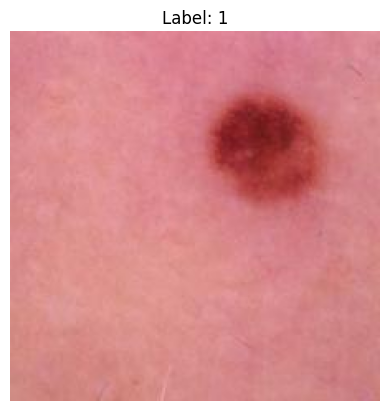

In [21]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.title(f"Label: {label}")
plt.axis("off")

### Test Transform

In [23]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from src.data.dataset import HAM10000Dataset
from src.data.transform import get_train_transforms, get_eval_transforms

train_dataset = HAM10000Dataset(
    csv_path="../data/splits/train.csv",
    image_dir="../data/raw/HAM10000/images",
    transform=get_train_transforms()
)

image, label = train_dataset[0]

print(type(image))
print(image.shape)
print(label)

<class 'torch.Tensor'>
torch.Size([3, 224, 224])
1
